# Training: topographic W_in (`BioLeakyRNNTopo`)

Copy of `01b_train_v2.ipynb` that uses `BioLeakyRNNTopo` with
`use_topo_input=True` and `use_sheet=True`, `hidden_size=144`,
`exc_ratio=100/144` (n_exc=100 forms a 10x10 E sheet, n_inh=44).

Checkpoints: `../checkpoints/stage{0,1,2}_topo.pt` — isolated from
existing `_v2` weights.


In [1]:
import sys

sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.model_topo import BioLeakyRNNTopo
from src.plotting_topo import plot_rf_drive, plot_sheet_layout, plot_fix_weights
from src.env import CuedTargetWithDistractorsV3
from src.training import TrainConfig, train_supervised

device = "cpu"
print("device:", device)
Path("../checkpoints").mkdir(exist_ok=True)

device: cpu


## Ablation: stim_on and cue_on removed

Training uses `NoTimingMarkersEnv` — a subclass of `CuedTargetWithDistractorsV3`
that zeros **both** the `cue_on` (channel 1) and `stim_on` (channel 4)
channels in every trial. This removes two shortcut signals that earlier
trainings exploited:
- `stim_on` was used as a pure timing marker for target detection
  (original ablation in the previous iteration).
- `cue_on` was used as a pure timing marker for the cue epoch — lesion
  tests showed the network relied on it (zeroing it dropped accuracy
  0.80 → 0.39) without actually decoding *where* the cue pointed
  (zeroing `cue_x/cue_y` left accuracy at 0.81).

With both markers absent, the only way to detect either the cue epoch
or the target is via non-zero `cue_x/cue_y` or `stim_x/stim_y` drive
through the frozen topographic `W_in_topo`, so the network is forced to
use spatial structure for both events.

The environment source (`src/env.py`) is untouched — the ablation is a
notebook-only subclass.


In [3]:
def make_model():
    return BioLeakyRNNTopo(
        input_size=7,
        hidden_size=180,
        output_size=2,
        dt=20.0,
        tau=100.0,
        activation="softplus",
        sigma_rec=0.10,
        rec_init="diag",
        use_ei=True,
        exc_ratio=0.80,
        use_dale=True,
        mask_seed=42,
        sheet_side=12,
        tau_ee=0.25,
        tau_ie=0.32,
        tau_ei=0.64,
        tau_ii=0.64,
        rf_sigma=0.3,
    ).to(device)

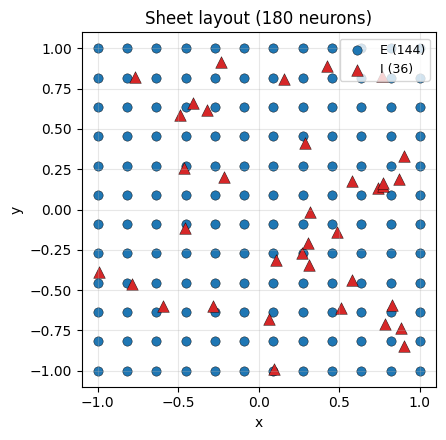

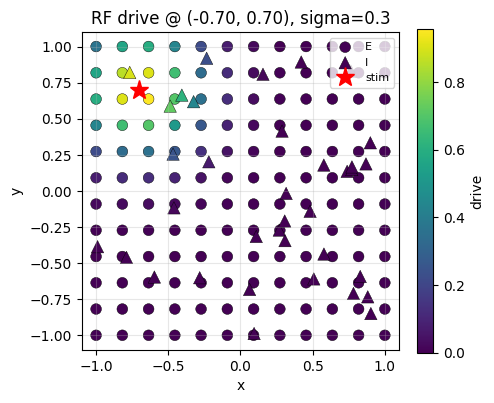

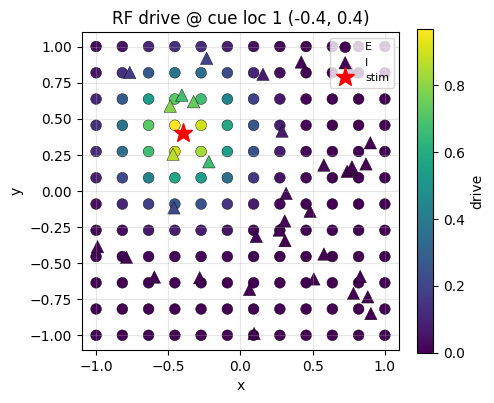

In [4]:
# Sanity: visualize sheet (E integer grid + I random points) and a sample
# RF drive at stim=(1, 1) to confirm geometric input path works.
m0 = make_model()
plot_sheet_layout(m0)
plt.show()
plot_rf_drive(m0, stim_xy=(-0.7, 0.7), strength=1.0)
plt.show()
plot_rf_drive(
    m0, stim_xy=(-0.4, 0.4), strength=1.0, title="RF drive @ cue loc 1 (-0.4, 0.4)"
)
plt.show()
del m0

## Stage 0 — detect target, no cue, no distractors

In [5]:
def make_env_stage0():
    return CuedTargetWithDistractorsV3(
        dt=20,
        cue_strength=0.0,
        p_distractor_trial=0.0,
        distractor_strength=0.0,
        continuous_locations=True,
    )


model = make_model()
cfg0 = TrainConfig(
    batch_size=64,
    lr=1e-3,
    max_updates=1000,
    print_every=100,
    device=device,
    stop_on_no_miss=0,
    aux_xy_weight=0.0,
)
history0 = train_supervised(model, make_env_stage0, cfg0)
torch.save({"state_dict": model.state_dict()}, "../checkpoints/stage0_topo.pt")
print("Saved: checkpoints/stage0_topo.pt")

Upd     1/1000 | Loss 0.4174 | CE 0.4174 | FA_pen 0.0000 | Aux 0.0000 | hit   0.0%  miss 100.0%  abort   0.0%  FA   n/a (n=0)
Upd   100/1000 | Loss 0.2452 | CE 0.2452 | FA_pen 0.0000 | Aux 0.0000 | hit  35.9%  miss  39.1%  abort  25.0%  FA   n/a (n=0)
Upd   200/1000 | Loss 0.2499 | CE 0.2499 | FA_pen 0.0000 | Aux 0.0000 | hit  40.6%  miss  48.4%  abort  10.9%  FA   n/a (n=0)
Upd   300/1000 | Loss 0.2369 | CE 0.2369 | FA_pen 0.0000 | Aux 0.0000 | hit  48.4%  miss  35.9%  abort  15.6%  FA   n/a (n=0)
Upd   400/1000 | Loss 0.2331 | CE 0.2331 | FA_pen 0.0000 | Aux 0.0000 | hit  53.1%  miss  26.6%  abort  20.3%  FA   n/a (n=0)
Upd   500/1000 | Loss 0.2305 | CE 0.2305 | FA_pen 0.0000 | Aux 0.0000 | hit  45.3%  miss  29.7%  abort  25.0%  FA   n/a (n=0)
Upd   600/1000 | Loss 0.2466 | CE 0.2466 | FA_pen 0.0000 | Aux 0.0000 | hit  28.1%  miss  60.9%  abort  10.9%  FA   n/a (n=0)
Upd   700/1000 | Loss 0.2231 | CE 0.2230 | FA_pen 0.0000 | Aux 0.0000 | hit  40.6%  miss  18.8%  abort  40.6%  FA   n/

## Stage 1 — add cue

In [6]:
def make_env_stage1():
    return CuedTargetWithDistractorsV3(
        dt=20,
        cue_strength=1.0,
        p_distractor_trial=0.0,
        distractor_strength=0.0,
        continuous_locations=True,
    )


model = make_model()
model.load_state_dict(
    torch.load("../checkpoints/stage0_topo.pt", weights_only=True)["state_dict"],
    strict=False,
)
cfg1 = TrainConfig(
    batch_size=64,
    lr=1e-3,
    max_updates=1000,
    print_every=100,
    device=device,
    stop_on_no_miss=0,
    aux_xy_weight=0.0,
)
history1 = train_supervised(model, make_env_stage1, cfg1)
torch.save({"state_dict": model.state_dict()}, "../checkpoints/stage1_topo.pt")
print("Saved: checkpoints/stage1_topo.pt")

Upd     1/1000 | Loss 0.2412 | CE 0.2412 | FA_pen 0.0000 | Aux 0.0000 | hit  54.7%  miss  12.5%  abort  32.8%  FA   n/a (n=0)
Upd   100/1000 | Loss 0.2188 | CE 0.2188 | FA_pen 0.0000 | Aux 0.0000 | hit  57.8%  miss  12.5%  abort  29.7%  FA   n/a (n=0)
Upd   200/1000 | Loss 0.2227 | CE 0.2227 | FA_pen 0.0000 | Aux 0.0000 | hit  54.7%  miss  12.5%  abort  32.8%  FA   n/a (n=0)
Upd   300/1000 | Loss 0.2226 | CE 0.2226 | FA_pen 0.0000 | Aux 0.0000 | hit  50.0%  miss  32.8%  abort  17.2%  FA   n/a (n=0)
Upd   400/1000 | Loss 0.2031 | CE 0.2031 | FA_pen 0.0000 | Aux 0.0000 | hit  45.3%  miss  31.2%  abort  23.4%  FA   n/a (n=0)
Upd   500/1000 | Loss 0.2118 | CE 0.2118 | FA_pen 0.0000 | Aux 0.0000 | hit  57.8%  miss  20.3%  abort  21.9%  FA   n/a (n=0)
Upd   600/1000 | Loss 0.2300 | CE 0.2300 | FA_pen 0.0000 | Aux 0.0000 | hit  26.6%  miss  70.3%  abort   3.1%  FA   n/a (n=0)
Upd   700/1000 | Loss 0.2160 | CE 0.2160 | FA_pen 0.0000 | Aux 0.0000 | hit  40.6%  miss  35.9%  abort  23.4%  FA   n/

## Stage 2 — cue + distractors (with early stopping)

In [7]:
def make_env_stage2():
    return CuedTargetWithDistractorsV3(
        dt=20,
        cue_strength=1.0,
        p_distractor_trial=0.6,
        distractor_strength=1.0,
        continuous_locations=True,
    )


model = make_model()
model.load_state_dict(
    torch.load("../checkpoints/stage1_topo.pt", weights_only=True)["state_dict"],
    strict=False,
)
cfg2 = TrainConfig(
    batch_size=64,
    lr=1e-3,
    max_updates=15000,
    print_every=50,
    device=device,
    aux_xy_weight=0.0,
)  # early stopping enabled (default stop_on_no_miss=3)
history2 = train_supervised(model, make_env_stage2, cfg2)
torch.save({"state_dict": model.state_dict()}, "../checkpoints/stage2_topo.pt")
print("Saved: checkpoints/stage2_topo.pt")

Upd     1/15000 | Loss 0.2533 | CE 0.2060 | FA_pen 0.1182 | Aux 0.0000 | hit  46.9%  miss  37.5%  abort  15.6%  FA  25.7% (n=35)
Upd    50/15000 | Loss 0.2674 | CE 0.2173 | FA_pen 0.1253 | Aux 0.0000 | hit  39.1%  miss  21.9%  abort  39.1%  FA  30.3% (n=33)
Upd   100/15000 | Loss 0.2632 | CE 0.2354 | FA_pen 0.0695 | Aux 0.0000 | hit  25.0%  miss  65.6%  abort   9.4%  FA   6.8% (n=44)
Upd   150/15000 | Loss 0.2392 | CE 0.2170 | FA_pen 0.0555 | Aux 0.0000 | hit  42.2%  miss  37.5%  abort  20.3%  FA  15.8% (n=38)
Upd   200/15000 | Loss 0.2459 | CE 0.2311 | FA_pen 0.0370 | Aux 0.0000 | hit  28.1%  miss  53.1%  abort  18.8%  FA   5.0% (n=40)
Upd   250/15000 | Loss 0.2452 | CE 0.2275 | FA_pen 0.0441 | Aux 0.0000 | hit  39.1%  miss  53.1%  abort   7.8%  FA   6.9% (n=29)
Upd   300/15000 | Loss 0.2308 | CE 0.2131 | FA_pen 0.0441 | Aux 0.0000 | hit  42.2%  miss  35.9%  abort  21.9%  FA   6.1% (n=33)
Upd   350/15000 | Loss 0.2315 | CE 0.1992 | FA_pen 0.0807 | Aux 0.0000 | hit  39.1%  miss  23.4% 

## Training curves

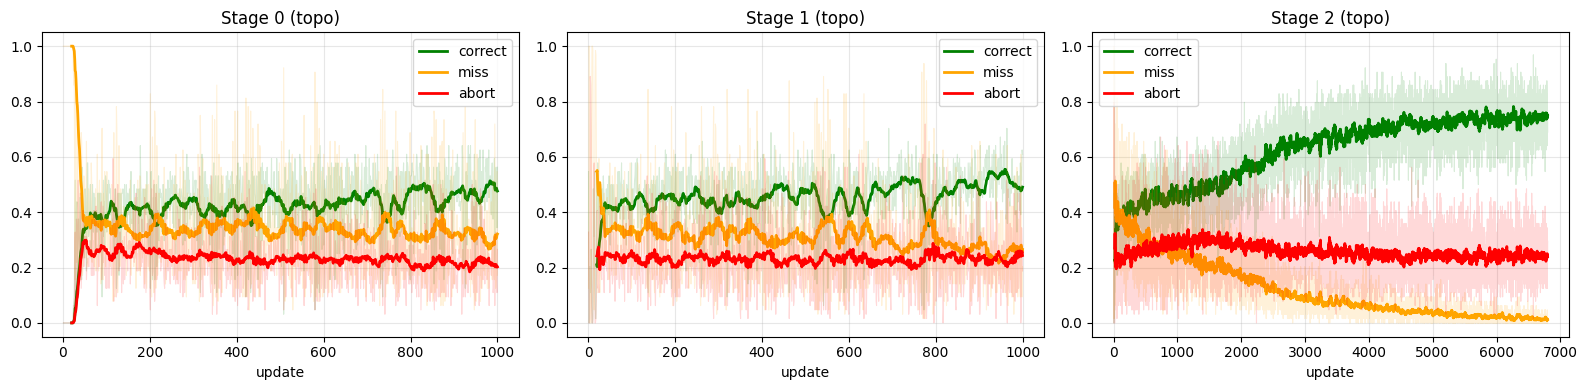

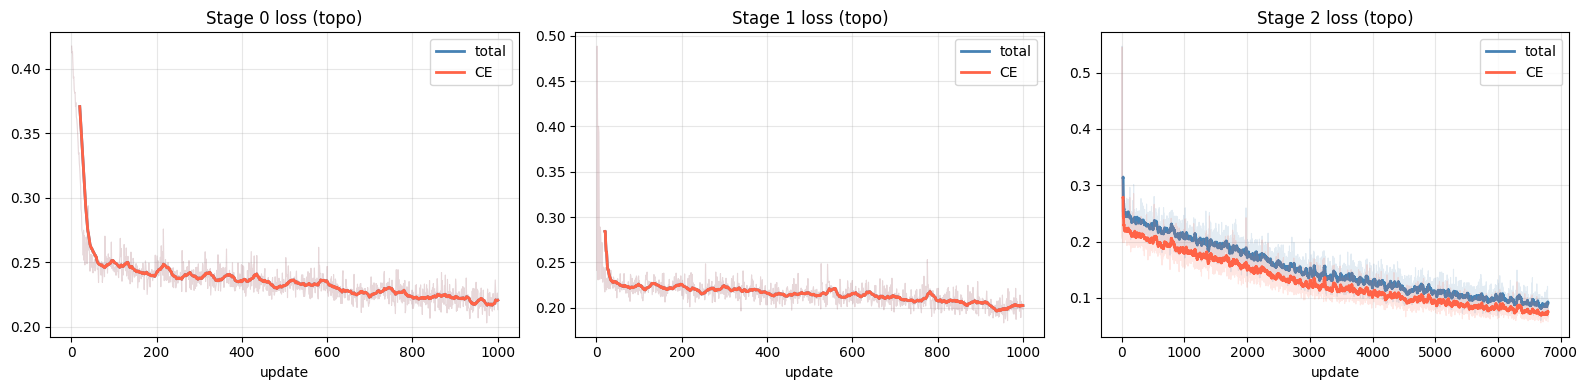

In [8]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode="valid")


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, hist, stage in zip(axes, [history0, history1, history2], [0, 1, 2]):
    updates = np.arange(1, len(hist["p_correct"]) + 1)
    sw = 20
    for key, color, label in [
        ("p_correct", "green", "correct"),
        ("p_miss", "orange", "miss"),
        ("p_abort", "red", "abort"),
    ]:
        vals = hist[key]
        ax.plot(updates, vals, alpha=0.15, color=color, lw=0.8)
        if len(vals) >= sw:
            ax.plot(updates[sw - 1 :], smooth(vals, sw), color=color, lw=2, label=label)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Stage {stage} (topo)")
    ax.set_xlabel("update")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, hist, stage in zip(axes, [history0, history1, history2], [0, 1, 2]):
    updates = np.arange(1, len(hist["loss"]) + 1)
    sw = 20
    ax.plot(updates, hist["loss"], alpha=0.15, color="steelblue", lw=0.8)
    if len(hist["loss"]) >= sw:
        ax.plot(
            updates[sw - 1 :],
            smooth(hist["loss"], sw),
            color="steelblue",
            lw=2,
            label="total",
        )
    ax.plot(updates, hist["ce"], alpha=0.15, color="tomato", lw=0.8)
    if len(hist["ce"]) >= sw:
        ax.plot(
            updates[sw - 1 :], smooth(hist["ce"], sw), color="tomato", lw=2, label="CE"
        )
    ax.set_title(f"Stage {stage} loss (topo)")
    ax.set_xlabel("update")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Quick eval on stage2_topo

In [9]:
from src.analysis import collect_trials, filter_trials

trials = collect_trials(model, make_env_stage2, n_trials=2000, device=device)
outcomes = {}
for tr in trials:
    o = tr["train_outcome"]
    outcomes[o] = outcomes.get(o, 0) + 1
total = len(trials)
print(f"Total trials: {total}")
for o, n in sorted(outcomes.items(), key=lambda x: -x[1]):
    print(f"  {o}: {n} ({100*n/total:.1f}%)")

KeyboardInterrupt: 